## Alexander Rees
## Andrew Lotocki
## Project Phase I
## DS 4420


# Scrape Data From CFB and Kaggle

In [1]:
!{sys.executable} -m pip install --upgrade kagglehub requests
!pip install pandas==2.2.2 numpy==1.26.4 requests==2.32.4 --force-reinstall
!pip install rapidfuzz

/bin/bash: line 1: {sys.executable}: command not found
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 382.3 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 553.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.8/64.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.7/153.7 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/216.6 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.0/349.0 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 7.5 MB/s e

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 31.7 MB/s eta 0:00:00


In [1]:
import sys
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import re
import requests
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from matplotlib.lines import Line2D
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from rapidfuzz import process, fuzz
from keras.models import Model
from keras.layers import Dense, Input, SimpleRNN
from keras.optimizers import SGD
from keras.losses import binary_crossentropy
import numpy as np
from dotenv import load_dotenv
import os

In [2]:
load_dotenv()
combine_file = 'nfl_combine_2010_to_2023.csv'
CFB_API_KEY = os.getenv("API_KEY")
headers = {"Authorization": f"Bearer {CFB_API_KEY}"}
years = list(range(2008, 2024))
combine_df = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, 'thomassshaw/nfl-combine-performance-dataset', path=combine_file)


def clean_name(name):
    if pd.isna(name):
        return None
    name = name.lower()
    name = re.sub(r"[^\w\s]", "", name)
    name = re.sub(r"\b(jr|sr|ii|iii|iv|v)\b", "", name)
    name = re.sub(r"\s+", " ", name)
    return name.strip()

position_map = {
    "wide receiver": "WR", "wr": "WR",
    "running back": "RB", "rb": "RB",
    "quarterback": "QB", "qb": "QB",
    "tight end": "TE", "te": "TE",
    "cornerback": "CB", "cb": "CB",
    "safety": "S", "s": "S",
    "linebacker": "LB", "lb": "LB",
    "defensive line": "DL", "dl": "DL",
    "defensive tackle": "DT", "dt": "DT",
    "defensive end": "DE", "de": "DE",
    "offensive line": "OL", "ol": "OL"
}

def clean_position(pos):
    if pd.isna(pos):
        return None
    pos = str(pos).lower().strip()
    return position_map.get(pos, pos.upper())

combine_df["clean_name"] = combine_df["Player"].apply(clean_name)
combine_df["position_clean"] = combine_df["Pos"].apply(clean_position)
combine_df["draft_year"] = combine_df["Year"]
cfb_list = []

for year in years:
    url = f"https://api.collegefootballdata.com/stats/player/season?year={year}"
    r = requests.get(url, headers=headers)
    data = r.json()

    if len(data) == 0:
        continue

    df = pd.DataFrame(data)
    df["clean_name"] = df["player"].apply(clean_name)
    df["position_clean"] = df["position"].apply(clean_position)
    df["season"] = year
    cfb_list.append(df)

cfb_df = pd.concat(cfb_list, ignore_index=True)
cfb_df["stat"] = cfb_df["stat"].astype(str)
cfb_df["stat"] = cfb_df["stat"].str.split("-").str[0]
cfb_df["stat"] = pd.to_numeric(cfb_df["stat"], errors="coerce")
cfb_df = cfb_df[cfb_df["stat"] < 10000]
last_season = cfb_df.groupby("clean_name")["season"].max().reset_index()
cfb_df = pd.merge(cfb_df, last_season, on=["clean_name", "season"], how="inner")

cfb_wide = cfb_df.pivot_table(
    index=["clean_name", "season", "position_clean"],
    columns=["category", "statType"],
    values="stat",
    aggfunc="sum"
).reset_index()

cfb_wide.columns = ["_".join(col).strip("_") if isinstance(col, tuple) else col for col in cfb_wide.columns]
cfb_wide.columns.name = None
cfb_by_position = {pos: group["clean_name"].dropna().values for pos, group in cfb_wide.groupby("position_clean")}
all_cfb_names = cfb_wide["clean_name"].dropna().values


def match_with_position(name, pos, threshold=88):
    if pd.isna(name):
        return None, 0

    choices = cfb_by_position.get(pos)
    if choices is None or len(choices) == 0:
        choices = all_cfb_names

    match = process.extractOne(
        name,
        choices,
        scorer=fuzz.token_sort_ratio)

    if match is None:
        return None, 0

    matched_name, score, _ = match

    if score >= threshold:
        return matched_name, score
    else:
        return None, score


matches = combine_df.apply(lambda row: match_with_position(row["clean_name"], row["position_clean"]), axis=1)

combine_df["matched_name"] = matches.apply(lambda x: x[0])
combine_df["match_score"] = matches.apply(lambda x: x[1])

merged_df = pd.merge(
    combine_df,
    cfb_wide,
    left_on="matched_name",
    right_on="clean_name",
    how="left",
    suffixes=("", "_cfb")
)


merged_df = merged_df[(merged_df["season"] >= merged_df["Year"] - 2) & (merged_df["season"] <= merged_df["Year"])]

merged_df = merged_df.sort_values("match_score", ascending=False)
merged_df = merged_df.drop_duplicates(subset=["Player", "Year"])
merged_df.to_csv("data/player_data.csv", index=False)

print("Match rate:", combine_df["matched_name"].notna().mean())
print(merged_df.head())

100%|██████████| 355k/355k [00:00<00:00, 387kB/s]


Match rate: 0.5292132461506012
      Year           Player Pos          School Height  Weight  40yd  \
0     2010   Seyi Ajirotutu  WR    Fresno State    6-3   204.0  4.60   
3582  2020     Josiah Scott  CB  Michigan State    5-9   185.0  4.42   
3563  2020  Michael Pittman  WR             USC    6-4   223.0  4.52   
3564  2020       Troy Pride  CB      Notre Dame   5-11   193.0  4.40   
3565  2020     James Proche  WR             SMU   5-11   201.0   NaN   

      Vertical  Bench  Broad Jump  ...  receiving_LONG  receiving_REC  \
0         36.0   14.0       115.0  ...            46.0           49.0   
3582       NaN   17.0         NaN  ...             NaN            NaN   
3563      36.5   13.0       121.0  ...            77.0          101.0   
3564      35.5   13.0       119.0  ...             NaN            NaN   
3565      34.5   20.0         NaN  ...            52.0          111.0   

      receiving_TD  receiving_YDS  receiving_YPR rushing_CAR rushing_LONG  \
0              7.0  

# Seperating Cleaning and Scaling our Data

In [3]:
df = pd.read_csv("data/player_data.csv")
df = df.drop(columns=['season', 'Year', 'clean_name', 'Round', 'School', 'clean_name_cfb','match_score','position_clean_cfb', 'position_clean', 'matched_name'])
df["Height"] = (df["Height"].astype(str).str.split("-").apply(lambda x: int(x[0]) * 12 + int(x[1]) if len(x) == 2 else None))
df["Drafted"] = df["Drafted"].fillna(0).astype(int)
cols = [c for c in df.columns if c not in ["Player", "Pos"]]
df[cols] = df[cols].astype(float)

qb_data = df[df["Pos"] == "QB"]
qb_data = qb_data.dropna(axis=1, thresh=len(qb_data) * 0.5).reset_index(drop=True)
qb_data = qb_data.fillna(0)

rb_data = df[df["Pos"] == "RB"]
rb_data = rb_data.dropna(axis=1, thresh=len(rb_data) * 0.5).reset_index(drop=True)
rb_data = rb_data.fillna(0)

cb_data = df[df["Pos"] == "CB"]
cb_data = cb_data.dropna(axis=1, thresh=len(cb_data) * 0.5).reset_index(drop=True)
cb_data = cb_data.fillna(0)

wr_data = df[df["Pos"] == "WR"]
wr_data = wr_data.dropna(axis=1, thresh=len(wr_data) * 0.5).reset_index(drop=True)
wr_data = wr_data.fillna(0)

de_data = df[df["Pos"] == "DE"]
de_data = de_data.dropna(axis=1, thresh=len(de_data) * 0.5).reset_index(drop=True)
de_data = de_data.fillna(0)

qb_data.to_csv("data/qb_data.csv", index=False)
rb_data.to_csv("data/rb_data.csv", index=False)
cb_data.to_csv("data/cb_data.csv", index=False)
wr_data.to_csv("data/wr_data.csv", index=False)
de_data.to_csv("data/de_data.csv", index=False)

In [4]:
print(qb_data.shape)
print(qb_data.columns)
qb_data.head()

(212, 24)
Index(['Player', 'Pos', 'Height', 'Weight', '40yd', 'Vertical', 'Broad Jump',
       '3Cone', 'Shuttle', 'Drafted', 'Pick', 'draft_year', 'passing_ATT',
       'passing_COMPLETIONS', 'passing_INT', 'passing_PCT', 'passing_TD',
       'passing_YDS', 'passing_YPA', 'rushing_CAR', 'rushing_LONG',
       'rushing_TD', 'rushing_YDS', 'rushing_YPC'],
      dtype='object')


,Player,Pos,Height,Weight,40yd,Vertical,Broad Jump,3Cone,Shuttle,Drafted,...,passing_INT,passing_PCT,passing_TD,passing_YDS,passing_YPA,rushing_CAR,rushing_LONG,rushing_TD,rushing_YDS,rushing_YPC
0,Shea Patterson,QB,73.0,212.0,4.71,31.0,116.0,7.14,4.50,0.0,...,8.0,0.562,23.0,3061.0,8.0,87.0,22.0,5.0,50.0,0.6
1,Tua Tagovailoa,QB,72.0,217.0,0.00,0.0,0.0,0.00,0.00,1.0,...,3.0,0.714,33.0,2840.0,11.3,23.0,25.0,2.0,17.0,0.7
2,Jalen Hurts,QB,73.0,222.0,4.59,35.0,125.0,0.00,0.00,1.0,...,8.0,0.695,32.0,3851.0,11.3,233.0,52.0,20.0,1298.0,5.6
3,Anthony Gordon,QB,74.0,205.0,0.00,0.0,0.0,0.00,0.00,0.0,...,16.0,0.716,48.0,5575.0,8.1,51.0,17.0,0.0,0.0,0.0
4,Justin Herbert,QB,78.0,236.0,4.68,35.5,123.0,7.06,4.46,1.0,...,6.0,0.668,32.0,3471.0,8.1,58.0,30.0,4.0,50.0,0.9


In [5]:
print(rb_data.shape)
print(rb_data.columns)
rb_data.head()

(338, 23)
Index(['Player', 'Pos', 'Height', 'Weight', '40yd', 'Vertical', 'Bench',
       'Broad Jump', '3Cone', 'Shuttle', 'Drafted', 'Pick', 'draft_year',
       'receiving_LONG', 'receiving_REC', 'receiving_TD', 'receiving_YDS',
       'receiving_YPR', 'rushing_CAR', 'rushing_LONG', 'rushing_TD',
       'rushing_YDS', 'rushing_YPC'],
      dtype='object')


,Player,Pos,Height,Weight,40yd,Vertical,Bench,Broad Jump,3Cone,Shuttle,...,receiving_LONG,receiving_REC,receiving_TD,receiving_YDS,receiving_YPR,rushing_CAR,rushing_LONG,rushing_TD,rushing_YDS,rushing_YPC
0,James Robinson,RB,69.0,219.0,4.64,40.0,24.0,125.0,7.03,4.19,...,12.0,2.0,0.0,10.0,5.0,13.0,18.0,0.0,16.0,1.2
1,Sewo Olonilua,RB,75.0,232.0,4.66,36.0,25.0,123.0,0.00,4.28,...,19.0,24.0,1.0,114.0,4.8,134.0,35.0,8.0,537.0,4.0
2,La'Mical Perine,RB,71.0,216.0,4.62,35.0,22.0,118.0,7.13,4.31,...,30.0,40.0,5.0,262.0,6.6,132.0,88.0,6.0,676.0,5.1
3,Scottie Phillips,RB,68.0,209.0,4.56,30.0,29.0,114.0,7.40,4.53,...,22.0,8.0,1.0,77.0,9.6,125.0,38.0,5.0,542.0,4.3
4,Ke'Shawn Vaughn,RB,70.0,214.0,4.51,32.0,0.0,117.0,0.00,0.00,...,61.0,28.0,1.0,270.0,9.6,198.0,75.0,9.0,1028.0,5.2


In [6]:
print(cb_data.shape)
print(cb_data.columns)
cb_data.head()

(211, 24)
Index(['Player', 'Pos', 'Height', 'Weight', '40yd', 'Vertical', 'Bench',
       'Broad Jump', '3Cone', 'Shuttle', 'Drafted', 'Pick', 'draft_year',
       'defensive_PD', 'defensive_QB HUR', 'defensive_SACKS', 'defensive_SOLO',
       'defensive_TD', 'defensive_TFL', 'defensive_TOT', 'interceptions_AVG',
       'interceptions_INT', 'interceptions_TD', 'interceptions_YDS'],
      dtype='object')


,Player,Pos,Height,Weight,40yd,Vertical,Bench,Broad Jump,3Cone,Shuttle,...,defensive_QB HUR,defensive_SACKS,defensive_SOLO,defensive_TD,defensive_TFL,defensive_TOT,interceptions_AVG,interceptions_INT,interceptions_TD,interceptions_YDS
0,Josiah Scott,CB,69.0,185.0,4.42,0.0,17.0,0.0,0.00,0.00,...,0.0,0.0,38.0,0.0,0.0,55.0,11.3,3.0,0.0,34.0
1,Troy Pride,CB,71.0,193.0,4.40,35.5,13.0,119.0,6.94,4.26,...,0.0,0.0,27.0,0.0,0.0,40.0,39.0,1.0,0.0,39.0
2,John Reid,CB,70.0,187.0,4.49,36.5,20.0,129.0,6.95,3.97,...,1.0,1.0,26.0,1.0,2.5,37.0,30.5,2.0,1.0,61.0
3,Amik Robertson,CB,68.0,187.0,0.00,0.0,0.0,0.0,0.00,0.00,...,1.0,1.0,44.0,3.0,8.0,60.0,19.4,5.0,2.0,97.0
4,James Pierre,CB,72.0,183.0,4.59,33.5,0.0,123.0,7.02,0.00,...,0.0,0.0,30.0,0.0,4.5,43.0,11.0,3.0,0.0,33.0


In [7]:
print(wr_data.shape)
print(wr_data.columns)
wr_data.head()

(558, 23)
Index(['Player', 'Pos', 'Height', 'Weight', '40yd', 'Vertical', 'Bench',
       'Broad Jump', '3Cone', 'Shuttle', 'Drafted', 'Pick', 'draft_year',
       'receiving_LONG', 'receiving_REC', 'receiving_TD', 'receiving_YDS',
       'receiving_YPR', 'rushing_CAR', 'rushing_LONG', 'rushing_TD',
       'rushing_YDS', 'rushing_YPC'],
      dtype='object')


,Player,Pos,Height,Weight,40yd,Vertical,Bench,Broad Jump,3Cone,Shuttle,...,receiving_LONG,receiving_REC,receiving_TD,receiving_YDS,receiving_YPR,rushing_CAR,rushing_LONG,rushing_TD,rushing_YDS,rushing_YPC
0,Seyi Ajirotutu,WR,75.0,204.0,4.60,36.0,14.0,115.0,7.22,4.39,...,46.0,49.0,7.0,677.0,13.8,0.0,0.0,0.0,0.0,0.0
1,Michael Pittman,WR,76.0,223.0,4.52,36.5,13.0,121.0,6.96,4.14,...,77.0,101.0,11.0,1275.0,12.6,0.0,0.0,0.0,0.0,0.0
2,James Proche,WR,71.0,201.0,0.00,34.5,20.0,0.0,7.27,4.40,...,52.0,111.0,15.0,1225.0,11.0,4.0,12.0,0.0,18.0,4.5
3,Jalen Reagor,WR,71.0,206.0,4.47,42.0,17.0,138.0,7.31,4.46,...,55.0,43.0,5.0,611.0,14.2,14.0,29.0,0.0,89.0,6.4
4,Joe Reed,WR,72.0,224.0,4.47,38.0,21.0,123.0,0.00,0.00,...,43.0,77.0,7.0,679.0,8.8,8.0,22.0,0.0,42.0,5.3


In [8]:
print(de_data.shape)
print(de_data.columns)
de_data.head()

(71, 20)
Index(['Player', 'Pos', 'Height', 'Weight', '40yd', 'Vertical', 'Bench',
       'Broad Jump', '3Cone', 'Shuttle', 'Drafted', 'Pick', 'draft_year',
       'defensive_PD', 'defensive_QB HUR', 'defensive_SACKS', 'defensive_SOLO',
       'defensive_TD', 'defensive_TFL', 'defensive_TOT'],
      dtype='object')


,Player,Pos,Height,Weight,40yd,Vertical,Bench,Broad Jump,3Cone,Shuttle,Drafted,Pick,draft_year,defensive_PD,defensive_QB HUR,defensive_SACKS,defensive_SOLO,defensive_TD,defensive_TFL,defensive_TOT
0,Victor Dimukeje,DE,73.0,262.0,4.87,34.5,28.0,115.0,7.25,4.35,1.0,210.0,2021.0,1.0,2.0,7.5,22.0,0.0,8.0,39.0
1,Jonathon Cooper,DE,74.0,253.0,4.69,33.0,28.0,108.0,6.99,4.31,1.0,239.0,2021.0,1.0,2.0,3.5,12.0,0.0,3.5,24.0
2,Kentavius Street,DE,74.0,280.0,4.87,0.0,28.0,0.0,0.00,0.00,1.0,128.0,2018.0,2.0,4.0,3.5,16.0,0.0,6.5,38.0
3,Joshua Paschal,DE,75.0,268.0,4.77,37.5,0.0,123.0,0.00,0.00,1.0,46.0,2022.0,0.0,8.0,5.0,24.0,0.0,15.0,52.0
4,Colby Wooden,DE,76.0,273.0,4.79,0.0,23.0,115.0,0.00,4.52,1.0,116.0,2023.0,3.0,10.0,6.0,36.0,0.0,11.5,45.0


# Building Our MPL Draft Prediction Models

### QB Model

In [29]:
qb_df = pd.read_csv("data/qb_data.csv")
y_qb = qb_df["Drafted"].to_numpy()
names = qb_df["Player"].values

X_qb = qb_df.drop(columns=["Player", "Pos", "Pick", "Drafted"]).to_numpy()
X_qb = MinMaxScaler().fit_transform(X_qb)

X_train, X_test, y_train, y_test, names_train, names_test = train_test_split(
    X_qb, y_qb, names, test_size=0.2, random_state=42)

In [30]:
inpx = Input(shape=(X_train.shape[1],))

hid_layer  = Dense(64, activation='relu')(inpx)
hid_layer2 = Dense(32,  activation='relu')(hid_layer)

out_layer  = Dense(1, activation='sigmoid')(hid_layer2)

model = Model([inpx], out_layer)

model.compile(optimizer=SGD(), loss=binary_crossentropy, metrics=['accuracy'])
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train.ravel())
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

model.fit(X_train, y_train, epochs=15, class_weight=class_weight_dict)

Epoch 1/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6391 - loss: 0.6853  
Epoch 2/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6509 - loss: 0.6825 
Epoch 3/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6509 - loss: 0.6809 
Epoch 4/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6391 - loss: 0.6796 
Epoch 5/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6627 - loss: 0.6783 
Epoch 6/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6686 - loss: 0.6764 
Epoch 7/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6272 - loss: 0.6750 
Epoch 8/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6509 - loss: 0.6745 
Epoch 9/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6391 - loss: 0.6727 
Epoch 10/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6391 - loss: 0.6719 
Epoch 11/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6213 - loss: 0.6704 
Epoch 12/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6509 - loss: 0.6692 


In [31]:
score = model.evaluate(X_test, y_test, verbose=0)
print('loss=', round(score[0],3))
print('accuracy=', round(score[1],3))

loss= 0.685
accuracy= 0.605


In [32]:
preds  = model.predict(X_test)
y_true = np.asarray(y_test).ravel().astype(int)
y_pred = (preds.reshape(-1) >= 0.5).astype(int)

table = pd.crosstab(y_pred, y_true, rownames=['Predicted'], colnames=['Actual'])
print(table)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Actual      0   1
Predicted        
0           4   5
1          12  22


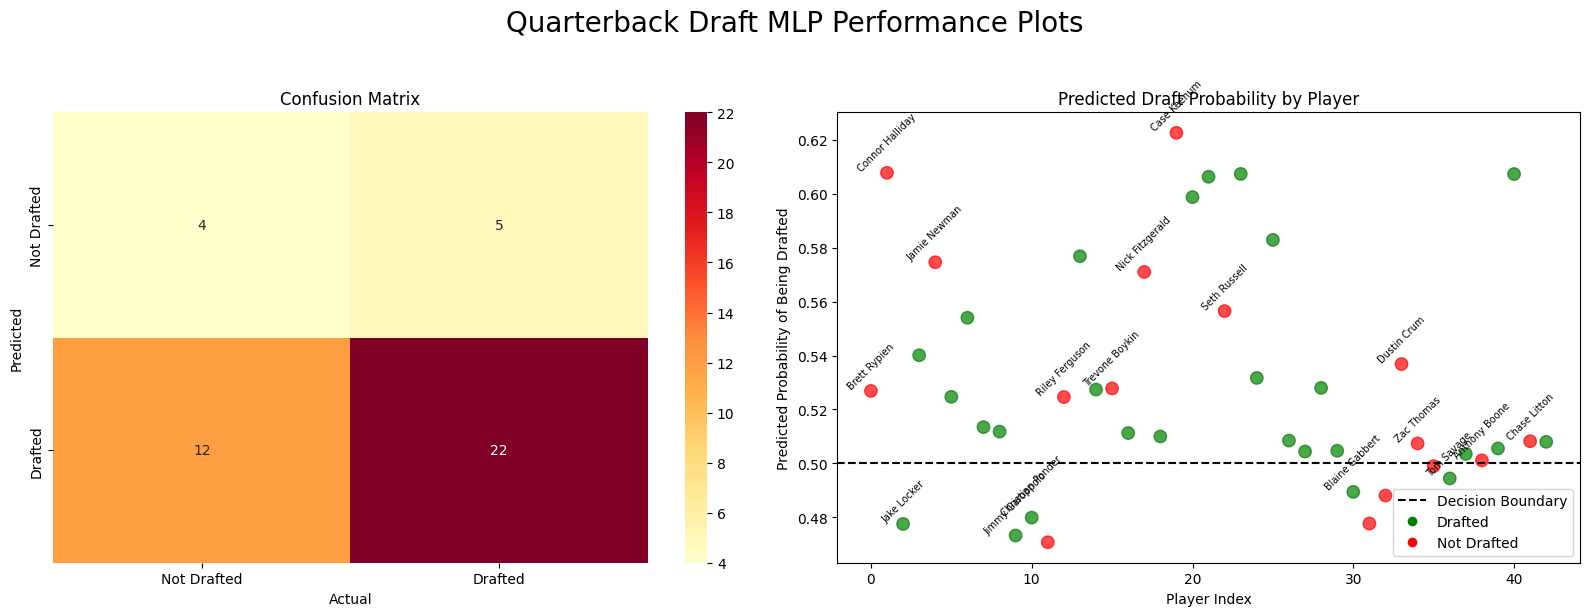

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Quarterback Draft MLP Performance Plots', fontsize=20, y=1.02)

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm.T, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0],
            xticklabels=['Not Drafted', 'Drafted'],
            yticklabels=['Not Drafted', 'Drafted'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Predicted')
axes[0].set_xlabel('Actual')


preds_flat = preds.reshape(-1)
colors = ['green' if y == 1 else 'red' for y in y_true]

axes[1].scatter(range(len(preds_flat)), preds_flat, c=colors, alpha=0.7, s=80)
axes[1].axhline(0.5, color='black', linestyle='--', label='Decision Boundary')

for i, name in enumerate(names_test):
    if y_true[i] != y_pred[i]:
        axes[1].annotate(name, (i, preds_flat[i]), fontsize=7, ha='center', va='bottom', rotation=45)

axes[1].set_title('Predicted Draft Probability by Player')
axes[1].set_xlabel('Player Index')
axes[1].set_ylabel('Predicted Probability of Being Drafted')

legend_elements = [
    Line2D([0], [0], color='black', linestyle='--', label='Decision Boundary'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='Drafted'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Not Drafted')
]
axes[1].legend(handles=legend_elements)

plt.tight_layout()
plt.show()

### RB Model

In [38]:
rb_df = pd.read_csv("data/rb_data.csv")
y_rb = rb_df["Drafted"].to_numpy()
names = rb_df["Player"].values

X_rb = rb_df.drop(columns=["Player", "Pos", "Pick", "Drafted"]).to_numpy()
X_rb = MinMaxScaler().fit_transform(X_rb)

X_train, X_test, y_train, y_test, names_train, names_test = train_test_split(
    X_rb, y_rb, names, test_size=0.2, random_state=42)

In [39]:
inpx = Input(shape=(X_train.shape[1],))

hid_layer  = Dense(256, activation='relu')(inpx)
hid_layer2 = Dense(128,  activation='relu')(hid_layer)

out_layer  = Dense(1, activation='sigmoid')(hid_layer2)

model = Model([inpx], out_layer)

model.compile(optimizer=SGD(), loss=binary_crossentropy, metrics=['accuracy'])
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train.ravel())
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

model.fit(X_train, y_train, epochs=20, class_weight=class_weight_dict)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4296 - loss: 0.6944  
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4593 - loss: 0.6926 
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4889 - loss: 0.6907 
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5333 - loss: 0.6889 
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5630 - loss: 0.6875 
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6259 - loss: 0.6862 
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6481 - loss: 0.6844
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6593 - loss: 0.6831 
Epoch 9/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6519 - loss: 0.6819
Epoch 10/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6481 - loss: 0.6807
Epoch 11/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6519 - loss: 0.6797 
Epoch 12/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6704 - loss: 0.6783 


In [40]:
score = model.evaluate(X_test, y_test, verbose=0)
print('loss=', round(score[0],3))
print('accuracy=', round(score[1],3))

loss= 0.676
accuracy= 0.618


In [41]:
preds  = model.predict(X_test)
y_true = np.asarray(y_test).ravel().astype(int)
y_pred = (preds.reshape(-1) >= 0.5).astype(int)

table = pd.crosstab(y_pred, y_true, rownames=['Predicted'], colnames=['Actual'])
print(table)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Actual      0   1
Predicted        
0          11  16
1          10  31


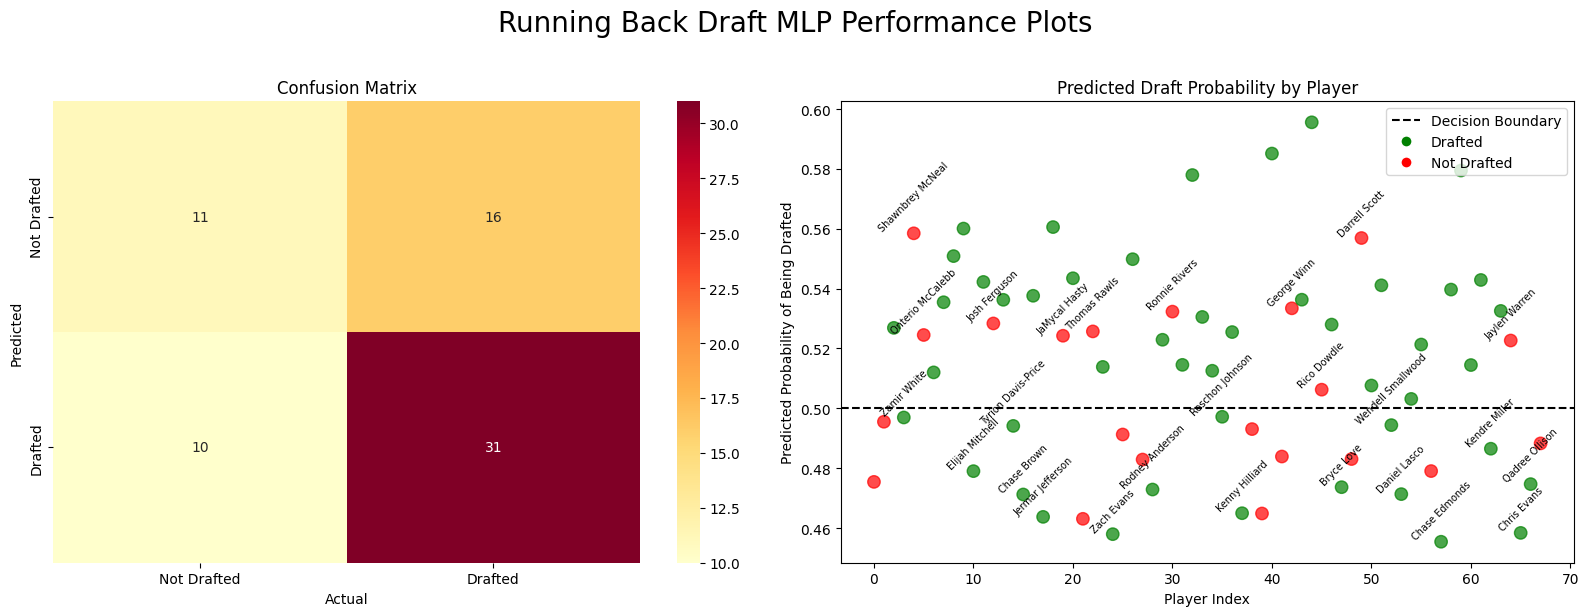

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Running Back Draft MLP Performance Plots', fontsize=20, y=1.02)

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm.T, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0],
            xticklabels=['Not Drafted', 'Drafted'],
            yticklabels=['Not Drafted', 'Drafted'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Predicted')
axes[0].set_xlabel('Actual')

preds_flat = preds.reshape(-1)
colors = ['green' if y == 1 else 'red' for y in y_true]

axes[1].scatter(range(len(preds_flat)), preds_flat, c=colors, alpha=0.7, s=80)
axes[1].axhline(0.5, color='black', linestyle='--', label='Decision Boundary')

for i, name in enumerate(names_test):
    if y_true[i] != y_pred[i]:
        axes[1].annotate(name, (i, preds_flat[i]), fontsize=7, ha='center', va='bottom', rotation=45)

axes[1].set_title('Predicted Draft Probability by Player')
axes[1].set_xlabel('Player Index')
axes[1].set_ylabel('Predicted Probability of Being Drafted')

legend_elements = [
    Line2D([0], [0], color='black', linestyle='--', label='Decision Boundary'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='Drafted'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Not Drafted')
]
axes[1].legend(handles=legend_elements)

plt.tight_layout()
plt.show()

### WR Model

In [46]:
wr_df = pd.read_csv("data/wr_data.csv")
y_wr = wr_df["Drafted"].to_numpy()
names = wr_df["Player"].values

X_wr = wr_df.drop(columns=["Player", "Pos", "Pick", "Drafted"]).to_numpy()
X_wr = MinMaxScaler().fit_transform(X_wr)

X_train, X_test, y_train, y_test, names_train, names_test = train_test_split(
    X_wr, y_wr, names, test_size=0.2, random_state=42)

In [47]:
inpx = Input(shape=(X_train.shape[1],))

hid_layer  = Dense(256, activation='relu')(inpx)
hid_layer2 = Dense(128,  activation='relu')(hid_layer)

out_layer  = Dense(1, activation='sigmoid')(hid_layer2)

model = Model([inpx], out_layer)

model.compile(optimizer=SGD(), loss=binary_crossentropy, metrics=['accuracy'])
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train.ravel())
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

model.fit(X_train, y_train, epochs=20, class_weight=class_weight_dict)

Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4395 - loss: 0.6953  
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4888 - loss: 0.6935 
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5404 - loss: 0.6916 
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5673 - loss: 0.6899 
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5471 - loss: 0.6884 
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6143 - loss: 0.6869 
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6211 - loss: 0.6854 
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6278 - loss: 0.6844 
Epoch 9/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6256 - loss: 0.6827 
Epoch 10/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6031 - loss: 0.6819 
Epoch 11/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6031 - loss: 0.6808 
Epoch 12/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy:

In [50]:
score = model.evaluate(X_test, y_test, verbose=0)
print('loss=', round(score[0],3))
print('accuracy=', round(score[1],3))

loss= 0.668
accuracy= 0.67


In [51]:
preds  = model.predict(X_test)
y_true = np.asarray(y_test).ravel().astype(int)
y_pred = (preds.reshape(-1) >= 0.5).astype(int)

table = pd.crosstab(y_pred, y_true, rownames=['Predicted'], colnames=['Actual'])
print(table)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Actual      0   1
Predicted        
0          27  19
1          18  48


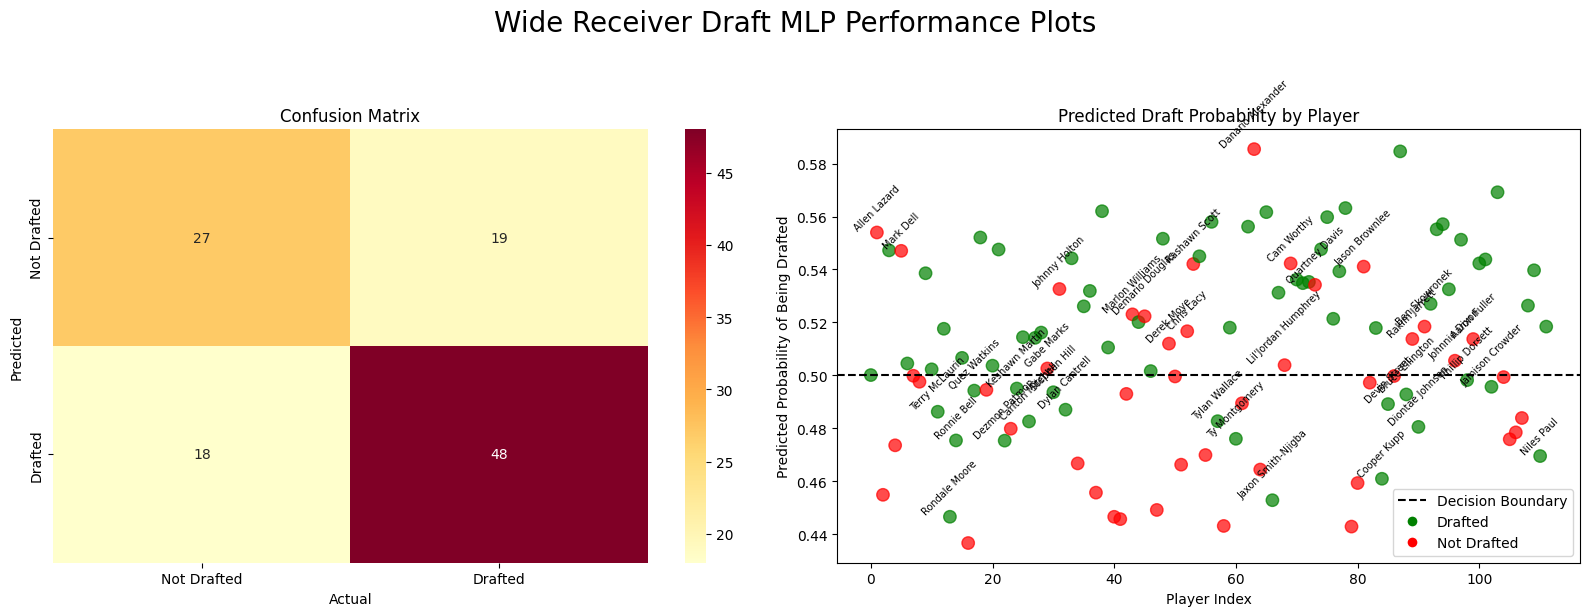

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Wide Receiver Draft MLP Performance Plots', fontsize=20, y=1.02)

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm.T, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0],
            xticklabels=['Not Drafted', 'Drafted'],
            yticklabels=['Not Drafted', 'Drafted'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Predicted')
axes[0].set_xlabel('Actual')


preds_flat = preds.reshape(-1)
colors = ['green' if y == 1 else 'red' for y in y_true]

axes[1].scatter(range(len(preds_flat)), preds_flat, c=colors, alpha=0.7, s=80)
axes[1].axhline(0.5, color='black', linestyle='--', label='Decision Boundary')

for i, name in enumerate(names_test):
    if y_true[i] != y_pred[i]:
        axes[1].annotate(name, (i, preds_flat[i]), fontsize=7, ha='center', va='bottom', rotation=45)

axes[1].set_title('Predicted Draft Probability by Player')
axes[1].set_xlabel('Player Index')
axes[1].set_ylabel('Predicted Probability of Being Drafted')

legend_elements = [
    Line2D([0], [0], color='black', linestyle='--', label='Decision Boundary'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='Drafted'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Not Drafted')
]
axes[1].legend(handles=legend_elements)

plt.tight_layout()
plt.show()

### CB Model

In [80]:
cb_df = pd.read_csv("data/cb_data.csv")
y_cb = cb_df["Drafted"].to_numpy()
names = cb_df["Player"].values

X_cb = cb_df.drop(columns=["Player", "Pos", "Pick", "Drafted"]).to_numpy()
X_cb = MinMaxScaler().fit_transform(X_cb)

X_train, X_test, y_train, y_test, names_train, names_test = train_test_split(
    X_cb, y_cb, names, test_size=0.2, random_state=42)

In [81]:
inpx = Input(shape=(X_train.shape[1],))

hid_layer  = Dense(256, activation='relu')(inpx)
hid_layer2 = Dense(128,  activation='relu')(hid_layer)

out_layer  = Dense(1, activation='sigmoid')(hid_layer2)

model = Model([inpx], out_layer)

model.compile(optimizer=SGD(), loss=binary_crossentropy, metrics=['accuracy'])
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train.ravel())
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

model.fit(X_train, y_train, epochs=15, class_weight=class_weight_dict)

Epoch 1/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7143 - loss: 0.7055
Epoch 2/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7143 - loss: 0.7032 
Epoch 3/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7143 - loss: 0.7003
Epoch 4/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7143 - loss: 0.6984
Epoch 5/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7143 - loss: 0.6973
Epoch 6/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7143 - loss: 0.6965
Epoch 7/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7143 - loss: 0.6951 
Epoch 8/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7143 - loss: 0.6939 
Epoch 9/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7143 - loss: 0.6933
Epoch 10/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7143 - loss: 0.6933 
Epoch 11/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7083 - loss: 0.6922 
Epoch 12/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7202 - loss: 0.6912 


In [82]:
score = model.evaluate(X_test, y_test, verbose=0)
print('loss=', round(score[0],3))
print('accuracy=', round(score[1],3))

loss= 0.672
accuracy= 0.721


In [83]:
preds  = model.predict(X_test)
y_true = np.asarray(y_test).ravel().astype(int)
y_pred = (preds.reshape(-1) >= 0.5).astype(int)

table = pd.crosstab(y_pred, y_true, rownames=['Predicted'], colnames=['Actual'])
print(table)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Actual      0   1
Predicted        
0           0   2
1          10  31


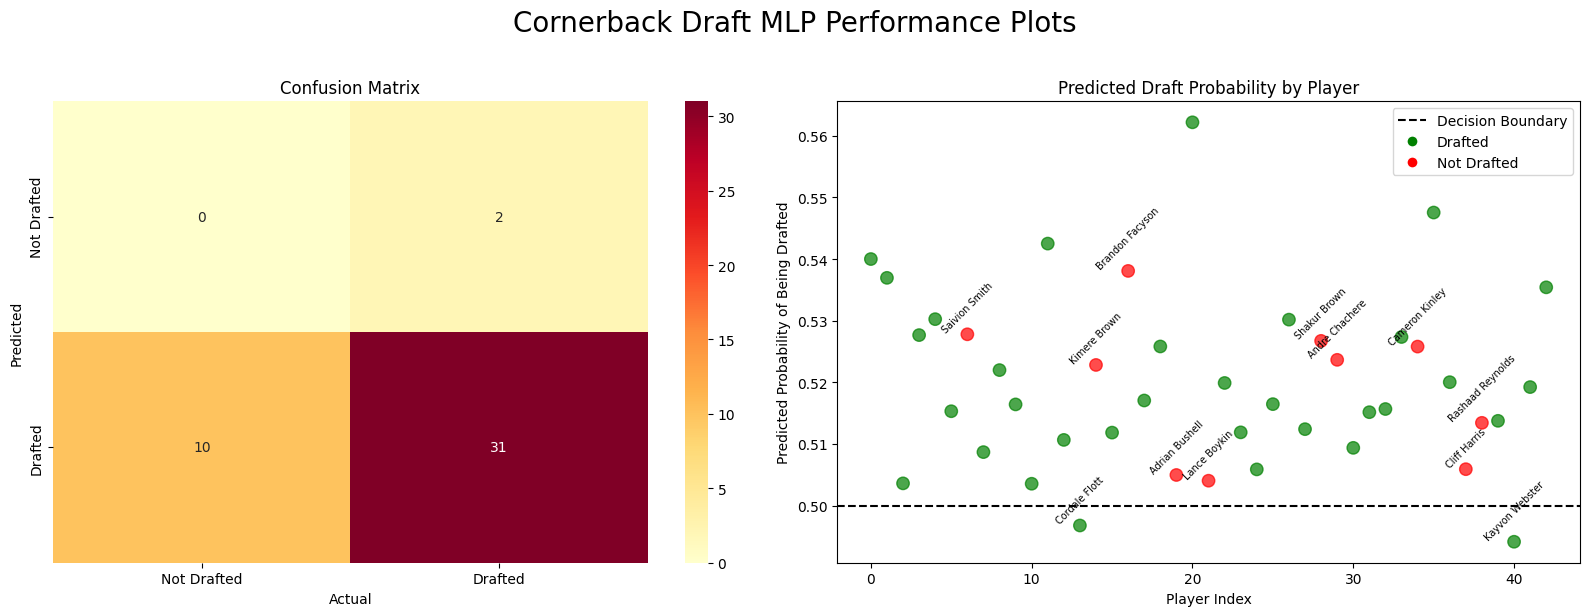

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Cornerback Draft MLP Performance Plots', fontsize=20, y=1.02)

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm.T, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0],
            xticklabels=['Not Drafted', 'Drafted'],
            yticklabels=['Not Drafted', 'Drafted'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Predicted')
axes[0].set_xlabel('Actual')

preds_flat = preds.reshape(-1)
colors = ['green' if y == 1 else 'red' for y in y_true]

axes[1].scatter(range(len(preds_flat)), preds_flat, c=colors, alpha=0.7, s=80)
axes[1].axhline(0.5, color='black', linestyle='--', label='Decision Boundary')

for i, name in enumerate(names_test):
    if y_true[i] != y_pred[i]:
        axes[1].annotate(name, (i, preds_flat[i]), fontsize=7, ha='center', va='bottom', rotation=45)

axes[1].set_title('Predicted Draft Probability by Player')
axes[1].set_xlabel('Player Index')
axes[1].set_ylabel('Predicted Probability of Being Drafted')

legend_elements = [
    Line2D([0], [0], color='black', linestyle='--', label='Decision Boundary'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='Drafted'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Not Drafted')
]
axes[1].legend(handles=legend_elements)

plt.tight_layout()
plt.show()

### DE Model

In [126]:
de_df = pd.read_csv("data/de_data.csv")
y_de = de_df["Drafted"].to_numpy()
names = de_df["Player"].values

X_de = de_df.drop(columns=["Player", "Pos", "Pick", "Drafted"]).to_numpy()
X_de = MinMaxScaler().fit_transform(X_de)

X_train, X_test, y_train, y_test, names_train, names_test = train_test_split(
    X_de, y_de, names, test_size=0.2, random_state=42)

In [127]:
inpx = Input(shape=(X_train.shape[1],))

hid_layer  = Dense(256, activation='relu')(inpx)
hid_layer2 = Dense(128,  activation='relu')(hid_layer)

out_layer  = Dense(1, activation='sigmoid')(hid_layer2)

model = Model([inpx], out_layer)

model.compile(optimizer=SGD(), loss=binary_crossentropy, metrics=['accuracy'])
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train.ravel())
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

model.fit(X_train, y_train, epochs=10, class_weight=class_weight_dict)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5000 - loss: 0.7064 
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5000 - loss: 0.7058
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5000 - loss: 0.7053
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5000 - loss: 0.7056
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5000 - loss: 0.7045
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5179 - loss: 0.7038
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5179 - loss: 0.7031
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5179 - loss: 0.7024
Epoch 9/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5179 - loss: 0.7020
Epoch 10/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5536 - loss: 0.7016


In [128]:
score = model.evaluate(X_test, y_test, verbose=0)
print('loss=', round(score[0],3))
print('accuracy=', round(score[1],3))

loss= 0.684
accuracy= 0.733


In [129]:
preds  = model.predict(X_test)
y_true = np.asarray(y_test).ravel().astype(int)
y_pred = (preds.reshape(-1) >= 0.5).astype(int)

table = pd.crosstab(y_pred, y_true, rownames=['Predicted'], colnames=['Actual'])
print(table)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Actual     0   1
Predicted       
0          1   2
1          2  10


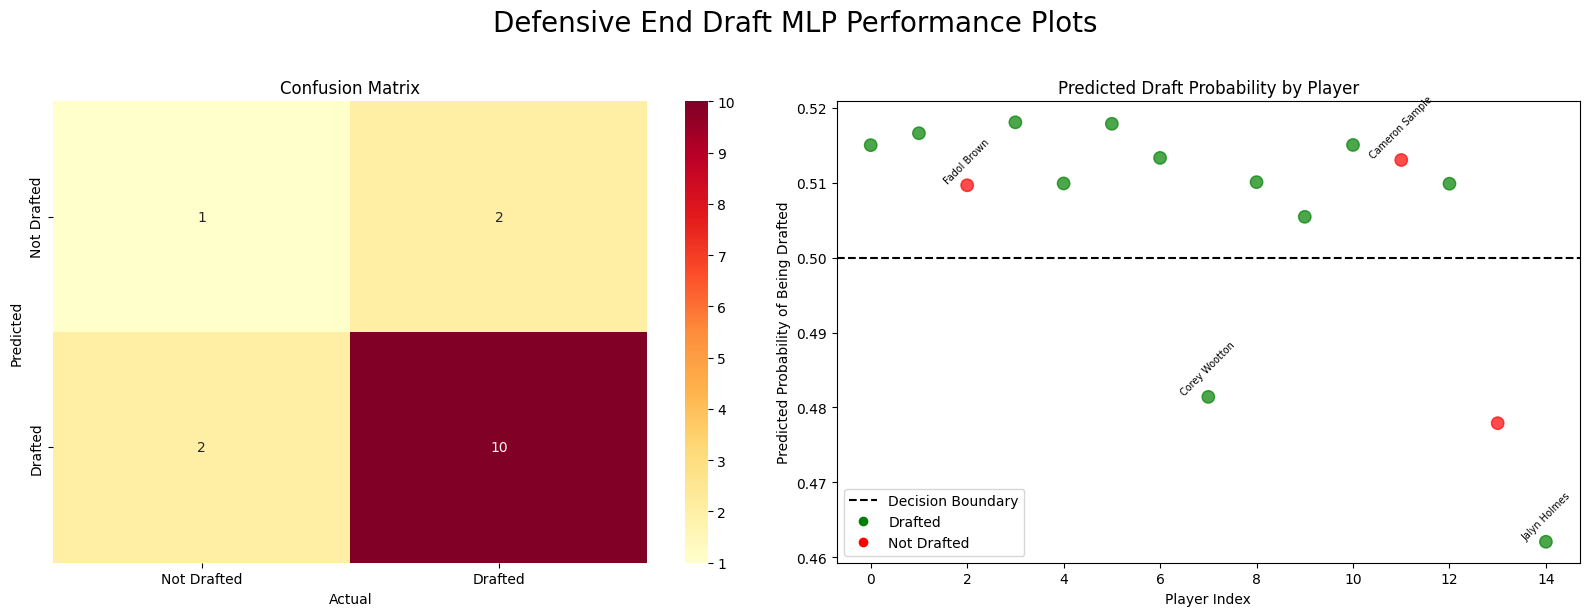

In [132]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Defensive End Draft MLP Performance Plots', fontsize=20, y=1.02)

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm.T, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0],
            xticklabels=['Not Drafted', 'Drafted'],
            yticklabels=['Not Drafted', 'Drafted'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Predicted')
axes[0].set_xlabel('Actual')


preds_flat = preds.reshape(-1)
colors = ['green' if y == 1 else 'red' for y in y_true]

axes[1].scatter(range(len(preds_flat)), preds_flat, c=colors, alpha=0.7, s=80)
axes[1].axhline(0.5, color='black', linestyle='--', label='Decision Boundary')

for i, name in enumerate(names_test):
    if y_true[i] != y_pred[i]:
        axes[1].annotate(name, (i, preds_flat[i]), fontsize=7, ha='center', va='bottom', rotation=45)

axes[1].set_title('Predicted Draft Probability by Player')
axes[1].set_xlabel('Player Index')
axes[1].set_ylabel('Predicted Probability of Being Drafted')

legend_elements = [
    Line2D([0], [0], color='black', linestyle='--', label='Decision Boundary'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='Drafted'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Not Drafted')
]
axes[1].legend(handles=legend_elements)

plt.tight_layout()
plt.show()